# 02 — Feature Exploration & Rolling Window Stability

This notebook explores:
- Per-trader feature distributions (skew, kurtosis, tail, capacity)
- Rolling mean/vol/Sharpe across different window lengths (20D / 40D / 60D)
- Cluster profile comparison (post-HDBSCAN)

Calls `src/` modules — no logic duplication.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Feature distributions

In [2]:
from src.profiling import FEATURE_COLUMNS, load_and_filter_features

df = load_and_filter_features(
    "../data/processed/trader_features.csv",
    min_active_days=20, min_active_ratio=0.2, max_gap_days=90
)
print(f"{len(df)} traders after filtering")
df[FEATURE_COLUMNS].describe().round(4)

/Users/luca/Projects/arkstream/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1063 traders after filtering


,mean_return,std_return,max_drawdown_synth,tail_avg_5pct,p5_return,ret_prev_equity_corr,avg_equity,max_net_deposit,mean_return_big_equity,mean_return_small_equity,acf1_return,acf1_abs_return
count,1063.0000,1063.0000,1063.0000,1063.0000,1063.0000,1063.0000,1.063000e+03,1.063000e+03,1063.0000,1057.0000,1063.0000,1063.0000
mean,0.0088,0.1015,0.5069,-0.1991,-0.1140,-0.1077,5.528796e+05,7.459681e+05,0.0037,0.0156,-0.0210,0.1970
std,0.0112,0.0829,0.3115,0.1780,0.1241,0.1702,3.007763e+06,4.845956e+06,0.0140,0.0375,0.1438,0.1691
min,-0.0781,0.0002,0.0002,-1.0000,-1.0000,-0.9998,1.534573e+03,1.000090e+03,-0.1656,-0.2000,-0.5200,-0.1478
25%,0.0022,0.0472,0.2323,-0.2614,-0.1534,-0.1720,9.134936e+03,5.716815e+03,-0.0020,0.0036,-0.0930,0.0689
50%,0.0066,0.0907,0.4883,-0.1594,-0.0871,-0.0914,3.084293e+04,2.341620e+04,0.0007,0.0100,-0.0205,0.1724
75%,0.0129,0.1323,0.7604,-0.0753,-0.0376,-0.0195,1.486669e+05,1.284590e+05,0.0072,0.0222,0.0417,0.2991
max,0.0840,0.9857,1.0000,-0.0001,0.0000,0.7679,5.631791e+07,8.502248e+07,0.1058,1.0000,0.7117,0.9588


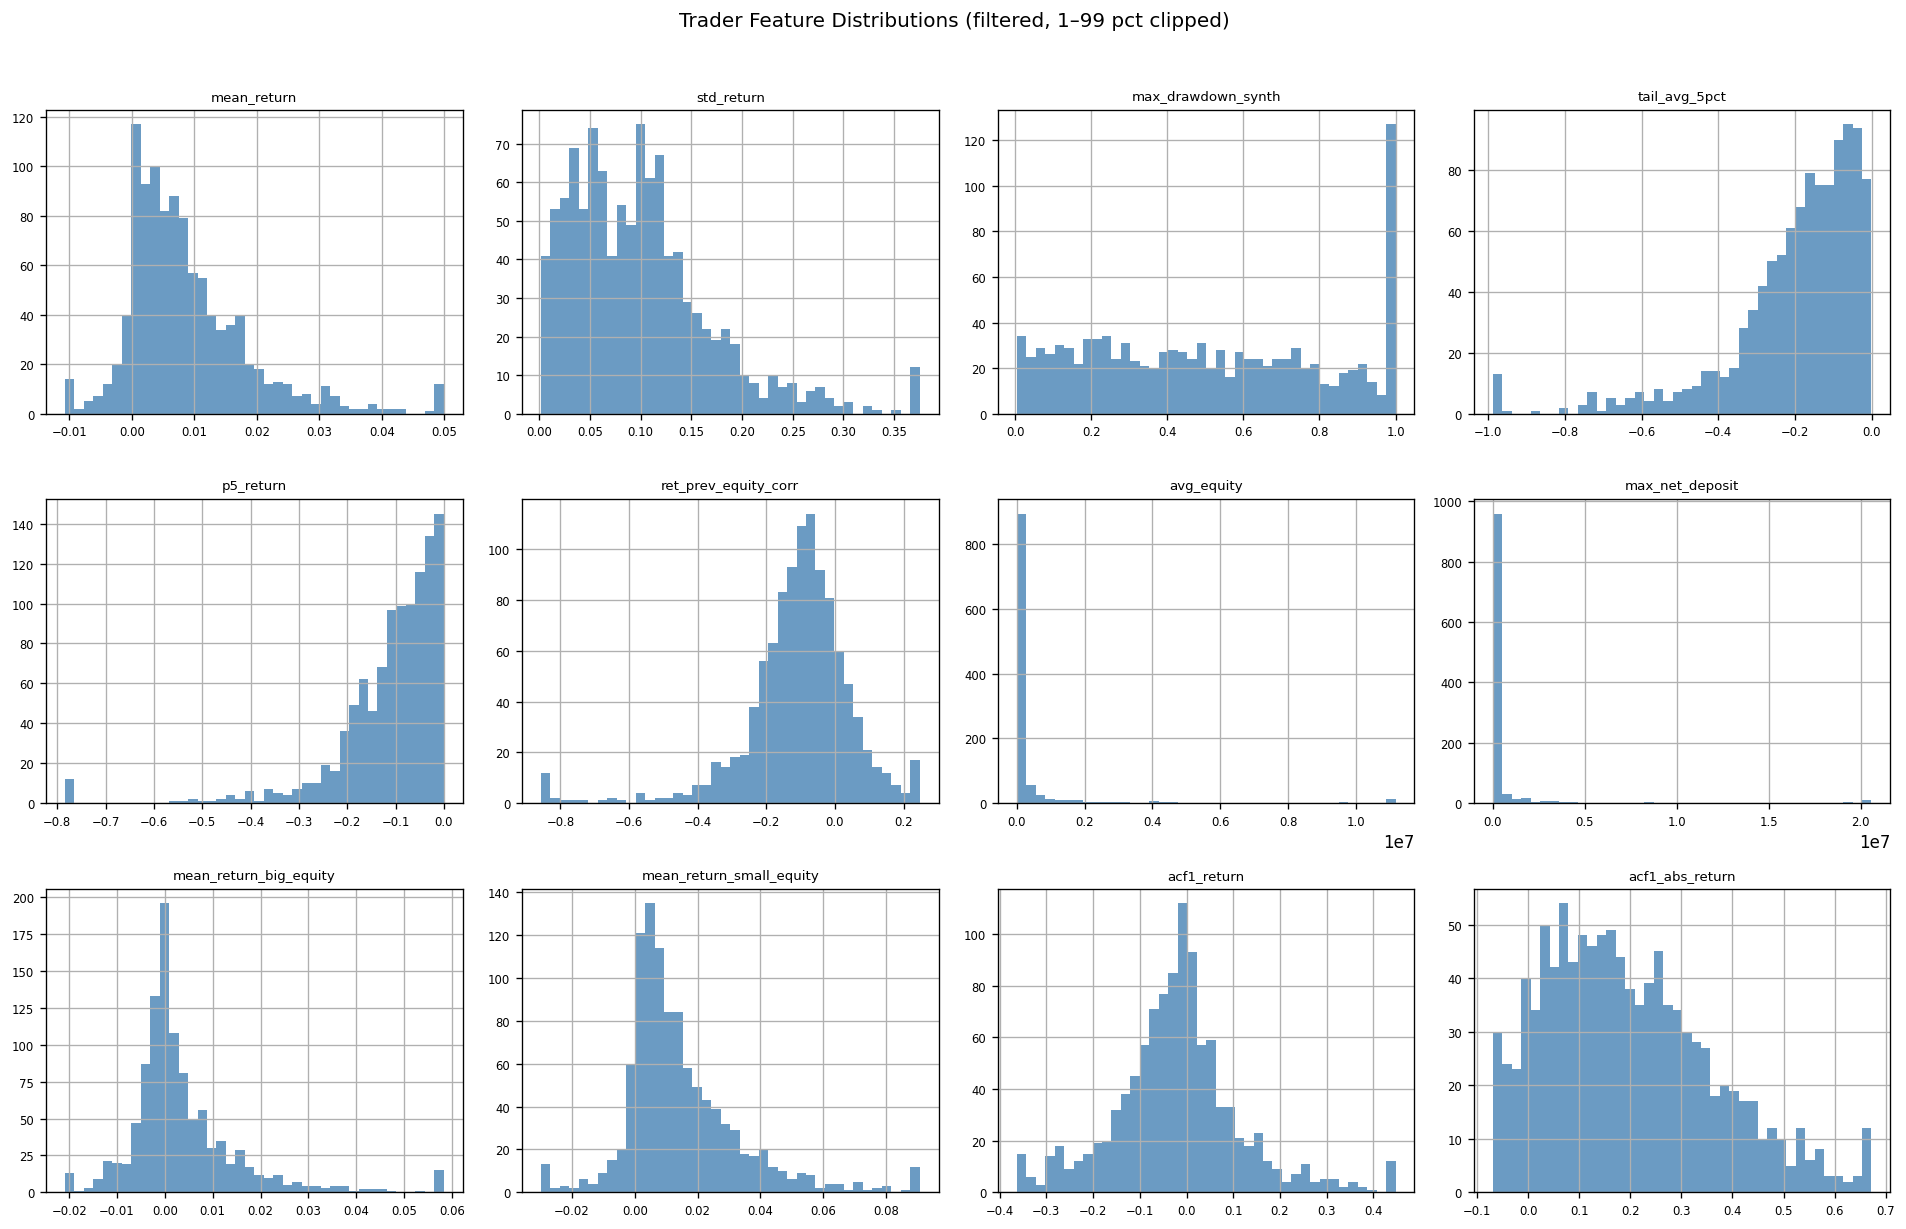

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i // 4][i % 4]
    vals = df[col].dropna()
    # clip extreme outliers for display
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    vals.clip(lo, hi).hist(bins=40, ax=ax, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)
plt.suptitle("Trader Feature Distributions (filtered, 1–99 pct clipped)", y=1.02)
plt.tight_layout()
plt.show()

## 2. Rolling window stability (20D / 40D / 60D)

In [4]:
from src.dataio import load_all_curves
from pathlib import Path

curves = load_all_curves(Path("../data/processed/trader_equity_curves"))
print(f"Loaded {len(curves)} trader equity curves")

# Pick a sample of traders with reasonable history
sample_traders = [
    t for t, eq in curves.items() if len(eq) >= 60
][:30]

# Align into a return matrix
ret_matrix = pd.DataFrame({
    t: curves[t].pct_change().clip(-1, 1)
    for t in sample_traders
}).dropna(how='all')

print(f"Return matrix shape: {ret_matrix.shape}")

Loaded 1765 trader equity curves
Return matrix shape: (177, 30)


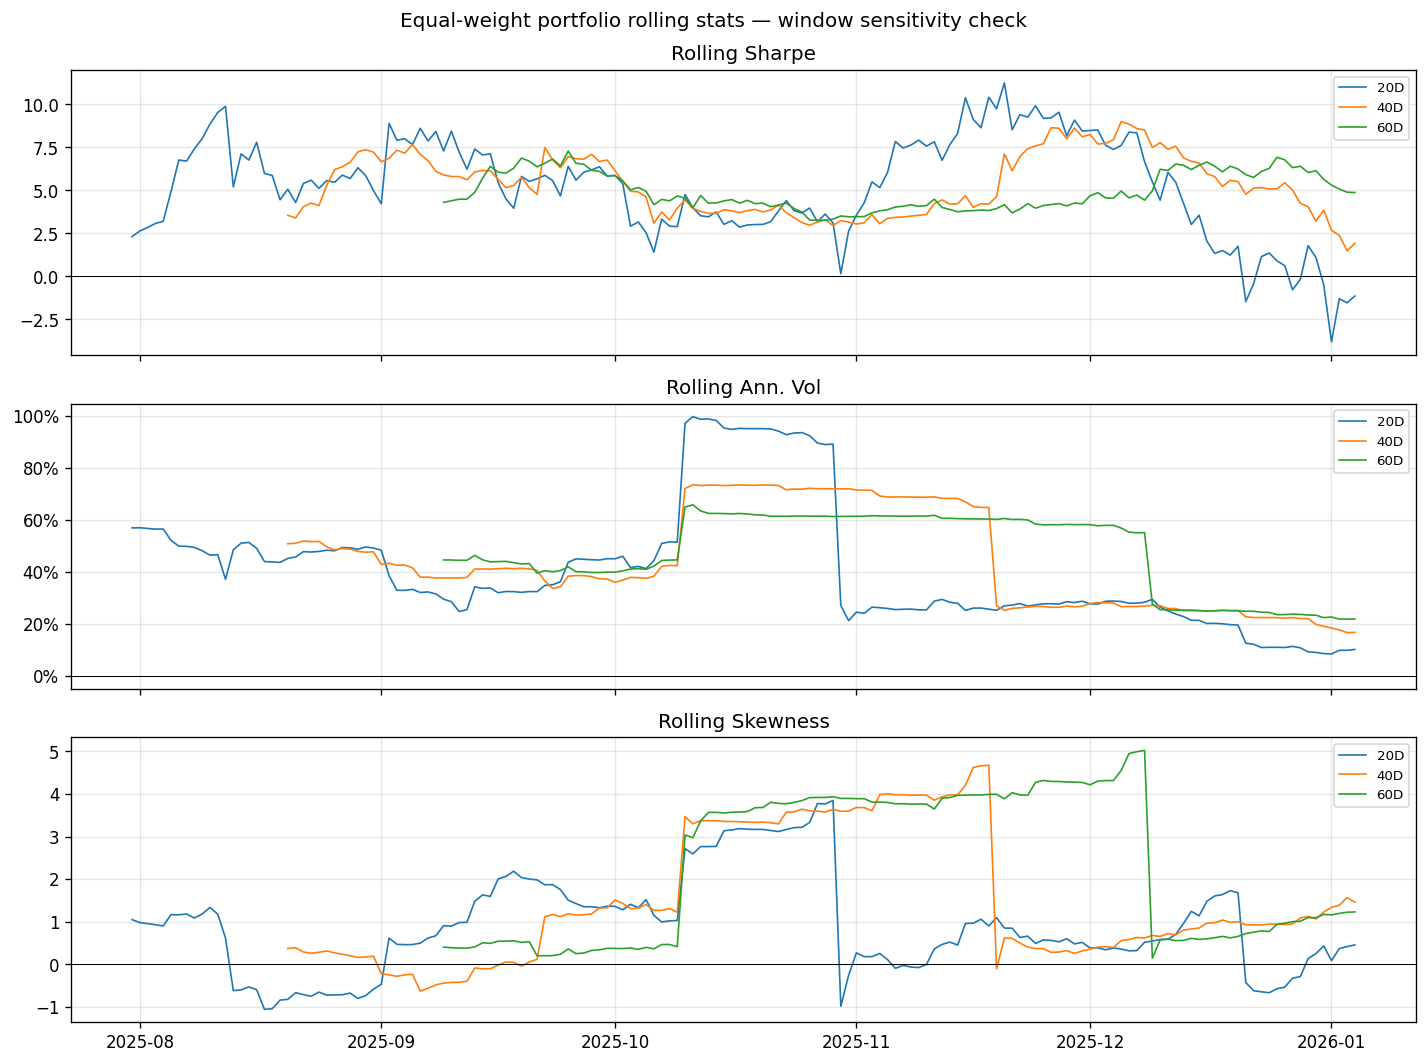

In [5]:
# Rolling portfolio-level statistics (equal-weight as a proxy)
port_ret = ret_matrix.mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
windows = [20, 40, 60]
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']

for w, c in zip(windows, colors):
    rolling_sharpe = (
        port_ret.rolling(w).mean() / port_ret.rolling(w).std()
    ) * (252 ** 0.5)
    axes[0].plot(rolling_sharpe, label=f"{w}D", color=c, linewidth=1)

    rolling_vol = port_ret.rolling(w).std() * (252 ** 0.5)
    axes[1].plot(rolling_vol, label=f"{w}D", color=c, linewidth=1)

    rolling_skew = port_ret.rolling(w).skew()
    axes[2].plot(rolling_skew, label=f"{w}D", color=c, linewidth=1)

for ax, title in zip(axes, ["Rolling Sharpe", "Rolling Ann. Vol", "Rolling Skewness"]):
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.6)

axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.suptitle("Equal-weight portfolio rolling stats — window sensitivity check")
plt.tight_layout()
plt.show()

## 3. Cluster profiles (post-HDBSCAN)

In [6]:
profiles = pd.read_csv("../data/processed/profiling_step3_cluster_profiles.csv")
profiles_clean = profiles[profiles['cluster'] != -1].copy()
display_cols = ['cluster', 'count', 'strategy_type',
                'median_mean_return', 'median_std_return',
                'median_max_drawdown_synth']
profiles_clean[display_cols].sort_values('cluster').reset_index(drop=True)

,cluster,count,strategy_type,median_mean_return,median_std_return,median_max_drawdown_synth
0,0,24,High risk / High return | Large size,0.007295,0.100797,0.568953
1,1,25,Low volatility | Negative AUM sensitivity | Sm...,0.001928,0.050023,0.442286
2,2,23,Higher mean return | Negative AUM sensitivity ...,0.021703,0.066772,0.085982
3,3,31,Negative AUM sensitivity | Small size | Mean-r...,0.006266,0.082081,0.445512
4,4,58,Higher tail risk | Vol clustering,0.000342,0.078626,0.700622
5,5,60,High risk / High return,0.014617,0.105021,0.494591
6,6,16,High risk / High return | Higher tail risk | N...,0.023541,0.170211,0.604557
7,7,65,High risk / High return | Higher tail risk | L...,0.008195,0.121596,0.708966
8,8,122,Low volatility,0.003620,0.041693,0.197606
9,9,27,Low volatility | Mean-reversion | Vol clustering,0.001359,0.017954,0.145173


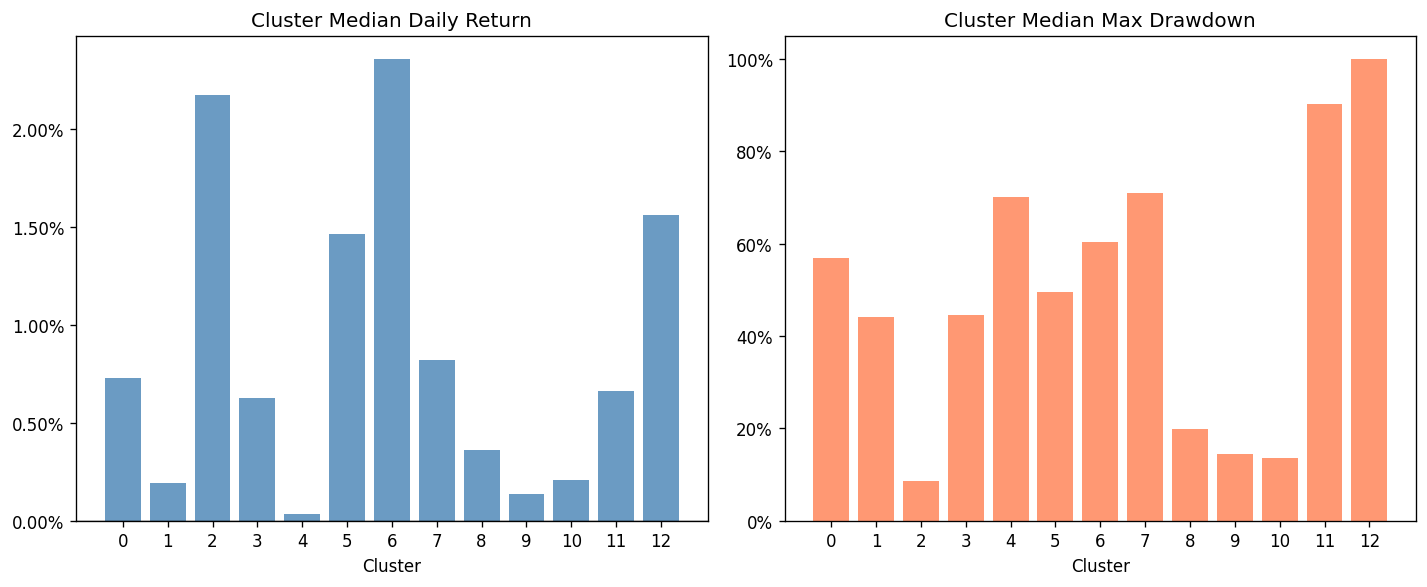

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
x = profiles_clean['cluster'].astype(str)
ax.bar(x, profiles_clean['median_mean_return'], color='steelblue', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("Cluster Median Daily Return")
ax.set_xlabel("Cluster")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax = axes[1]
ax.bar(x, profiles_clean['median_max_drawdown_synth'], color='coral', alpha=0.8)
ax.set_title("Cluster Median Max Drawdown")
ax.set_xlabel("Cluster")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()